# 🔮 Customer Churn Prediction

## From customer data to a retention decision

This notebook develops an end-to-end machine-learning workflow to predict whether a telecom customer is likely to **churn**—that is, leave the service.

> **Business question:** Which customers are at risk of leaving, and how reliably can the business identify them early enough to intervene?

### What this notebook delivers

| Area | What is covered |
|---|---|
| Data quality | Duplicate checks, missing-value treatment, outlier handling, and distribution review |
| Preparation | Encoding, scaling, feature selection, and class-imbalance handling |
| Modeling | Six tuned classification models with stratified cross-validation |
| Evaluation | Accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves |
| Decision support | A best-model review and practical customer-retention recommendations |

### Executive snapshot from the saved run

The data contains **7,043 customers** and a churn rate of about **26.5%**. The strongest final model by the chosen primary metric, **F1-score**, is **XGBoost** (F1 = **0.627**, recall = **0.751**, ROC-AUC = **0.832**).

---

**Important scope note.** The notebook preserves the existing workflow and saved outputs. Its conclusions should be validated on representative production data before being used to drive real customer actions.


## 🧭 Notebook roadmap

1. Load the customer dataset and inspect its structure  
2. Clean and validate the data  
3. Explore churn patterns visually  
4. Prepare features for machine learning  
5. Balance the training data with SMOTE  
6. Tune and compare six models  
7. Interpret the best result and turn it into business actions


## ⚙️ Setup and modeling toolkit

The next cell imports the libraries used for data manipulation, visualization, preprocessing, model selection, model training, and evaluation. A fixed random seed is used throughout the workflow where applicable so that the split and model results are reproducible.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import NearestNeighbors

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (confusion_matrix, classification_report, precision_score,
                              recall_score, f1_score, roc_auc_score, roc_curve, accuracy_score)

# XGBoost : try to import them; if not installed, fall back to an equivalent sklearn model
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    XGBClassifier = GradientBoostingClassifier  # equivalent fallback if xgboost isn't installed
    print("⚠️ xgboost not installed -> falling back to GradientBoostingClassifier. To install the real thing: pip install xgboost")

# imbalanced-learn for SMOTE
try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("⚠️ imbalanced-learn not installed -> falling back to a simple hand-built SMOTE implementation. To install the real thing: pip install imbalanced-learn")

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)

print("XGBoost available:", XGB_AVAILABLE)
print("imbalanced-learn available:", IMBLEARN_AVAILABLE)

XGBoost available: True
imbalanced-learn available: True


## 1. Load the dataset and establish a baseline

The dataset is loaded into a pandas DataFrame. The first checks confirm the dataset dimensions and give a quick preview of the customer-level fields.

### Data context

Each row represents one customer. The data combines customer profile attributes, subscribed services, account information, billing information, and the target field **`Churn`**.

| Field group | Examples in this dataset |
|---|---|
| Customer profile | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| Services | Internet service, security, support, streaming, phone service |
| Account & billing | `tenure`, contract type, payment method, monthly and total charges |
| Target | `Churn` — whether the customer left the service |

The output below confirms **7,043 rows** and **21 columns** at load time.


In [2]:
df = pd.read_csv("G:\download\Machine learing interner\Final\customer_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Reading the first inspection

The inspection cells above reveal the available fields, their types, and descriptive statistics. Before modeling, the workflow must make numerical fields usable, remove duplicate observations if any exist, and exclude identifier-only information such as `customerID`, which does not represent a behavior the model can generalize from.


## 2. Data quality and cleaning

This stage checks whether the input is suitable for analysis and modeling.

**Actions performed below**

- Check and remove duplicate customer records
- Convert charge-related columns to numeric values where necessary
- Remove the customer identifier from the modeling dataset
- Convert the target from a text label to a binary classification target

These choices ensure that the model learns from customer characteristics rather than a unique ID.


In [5]:
print("Duplicate rows before removal:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Row count after removing duplicates:", df.shape[0])

Duplicate rows before removal: 0
Row count after removing duplicates: 7043


In [6]:
# Make sure numeric columns are actually numeric (in the real dataset TotalCharges
# sometimes comes in as a string with blank spaces for brand-new customers)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')

customer_ids = df['customerID']            # keep it around in case we need it later
df = df.drop(columns=['customerID'])

# Encode the target as 0/1 (Yes -> 1, No -> 0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### Cleaning result

The saved run found **0 duplicate rows**, so the dataset remains at **7,043 customers**. The target has **5,174 non-churned customers** and **1,869 churned customers**. This confirms a meaningful class imbalance that will be addressed later using the training data only.


## 3. Missing values

Missing values can prevent models from training or distort comparisons. The next cells measure missingness, visualize affected columns, and impute values.

| Data type | Treatment used |
|---|---|
| Numeric fields | Median imputation |
| Categorical fields | Most-frequent-value imputation |

> **Method note:** In this educational workflow, imputation is performed before the train/test split. In a production pipeline, fit imputers on the training split only—ideally inside a `Pipeline`—to eliminate potential leakage.


TotalCharges    11
dtype: int64


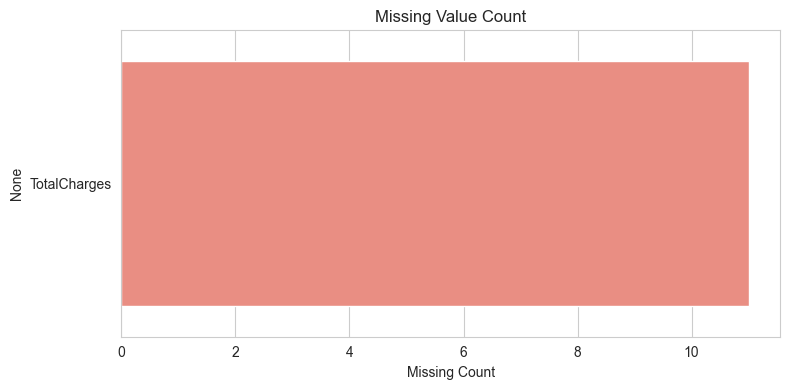

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(8,4))
sns.barplot(x=missing.values, y=missing.index, color='salmon')
plt.title('Missing Value Count')
plt.xlabel('Missing Count')
plt.tight_layout()
plt.show()

In [8]:
# Numeric columns: impute with the median (better than the mean since the distribution
# is skewed - we'll confirm this in the Skewness section)
num_missing_cols = ['MonthlyCharges', 'TotalCharges']
for col in num_missing_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns: impute with the mode (most frequent value)
cat_missing_cols = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()]
for col in cat_missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Total remaining missing values:", df.isnull().sum().sum())

Total remaining missing values: 0


### Missing-value result

Only **`TotalCharges`** has missing values in the saved run (**11 values**). After imputation, the notebook reports **0 remaining missing values**, so later preprocessing and modeling cells receive a complete dataset.


## 4. Exploratory data analysis (EDA)

EDA answers two practical questions before we train models:

1. **How common is churn?**
2. **Which customer characteristics appear to be associated with it?**

The visual checks below examine the target balance, key categorical groups, numerical distributions, potential outliers, and correlations.


### 4.1 Target distribution

The count plot below shows the balance between customers who stayed and customers who churned. The saved output corresponds to approximately **73.5% stayed** versus **26.5% churned**. This imbalance is why accuracy alone will not be enough to judge model quality.


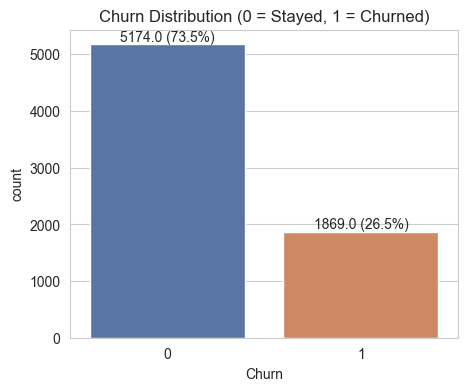

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [9]:
# Target distribution - to check the class imbalance
plt.figure(figsize=(5,4))
ax = sns.countplot(x='Churn', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Churn Distribution (0 = Stayed, 1 = Churned)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({100*p.get_height()/len(df):.1f}%)',
                (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.show()

df['Churn'].value_counts(normalize=True)

### 4.2 Categorical drivers of churn

The following grouped charts compare churn rates across contract type, internet service, payment method, senior-citizen status, partnership status, and technical support. These views help identify customer segments that may benefit from targeted retention actions.


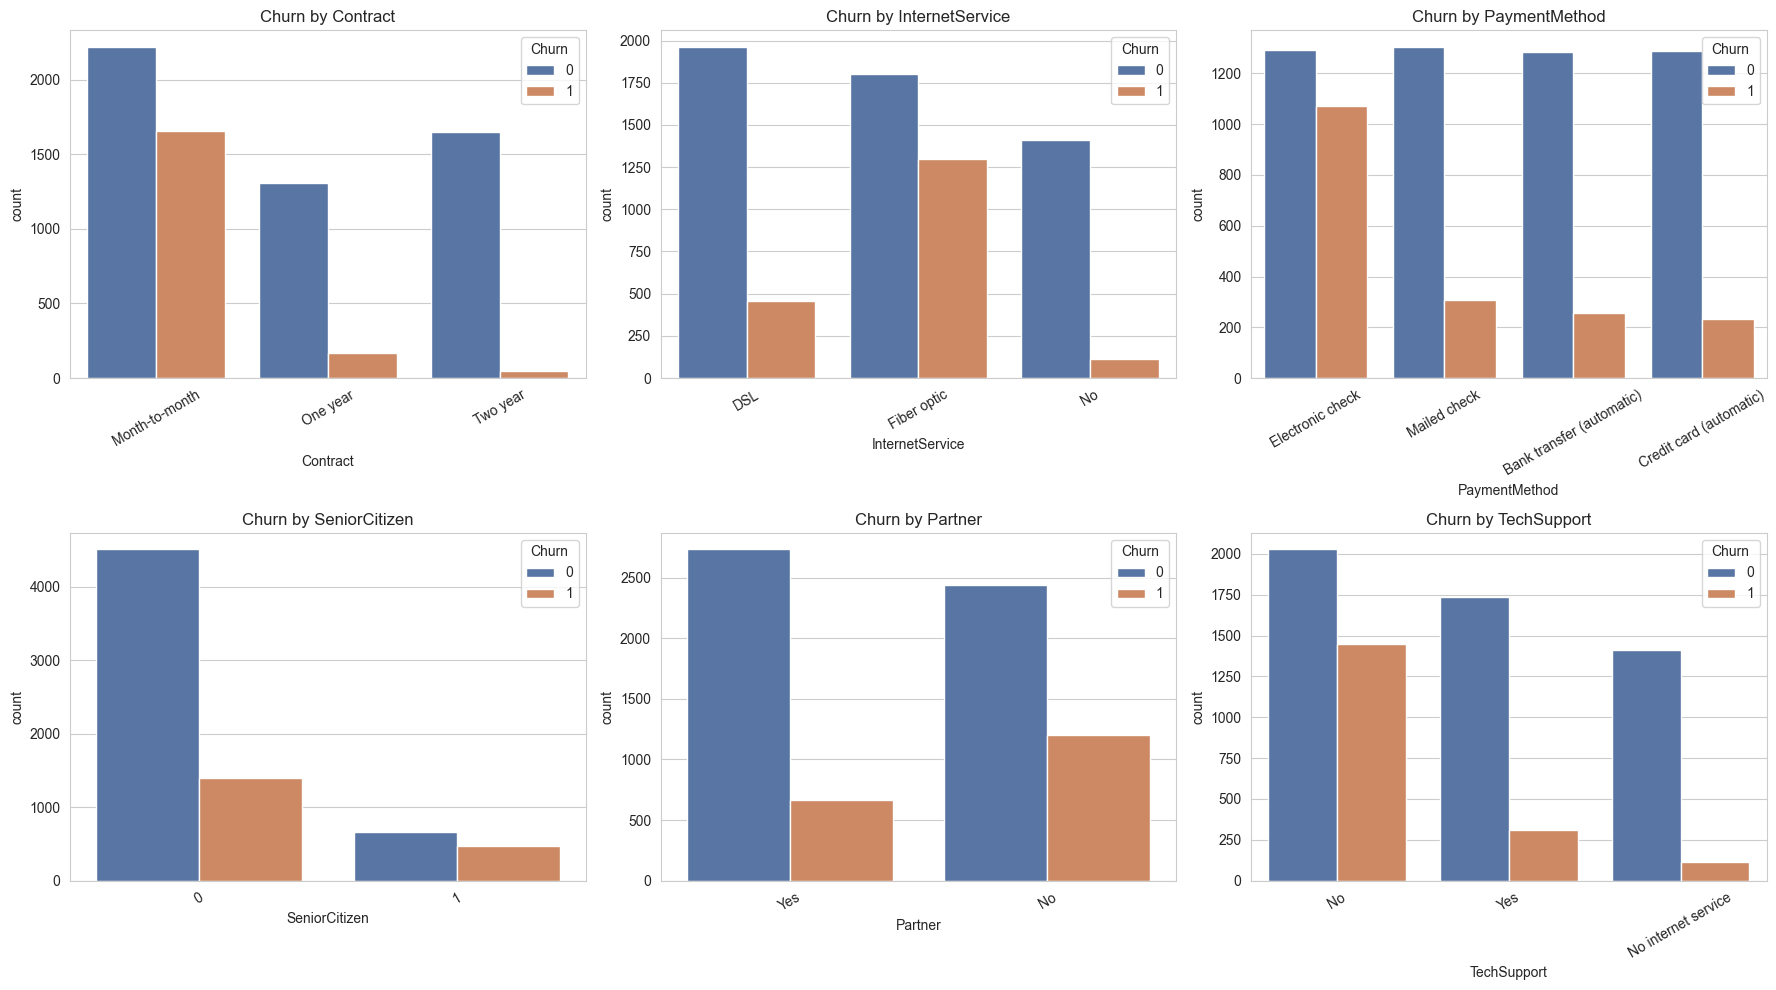

In [10]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen', 'Partner', 'TechSupport']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, ax=ax, palette=['#4C72B0', '#DD8452'])
    ax.set_title(f'Churn by {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 4.3 Numerical behavior by churn outcome

Histograms compare the distributions of **tenure**, **monthly charges**, and **total charges** for customers who stayed versus churned. The accompanying boxplots make central tendency and unusually large or small values easier to spot.


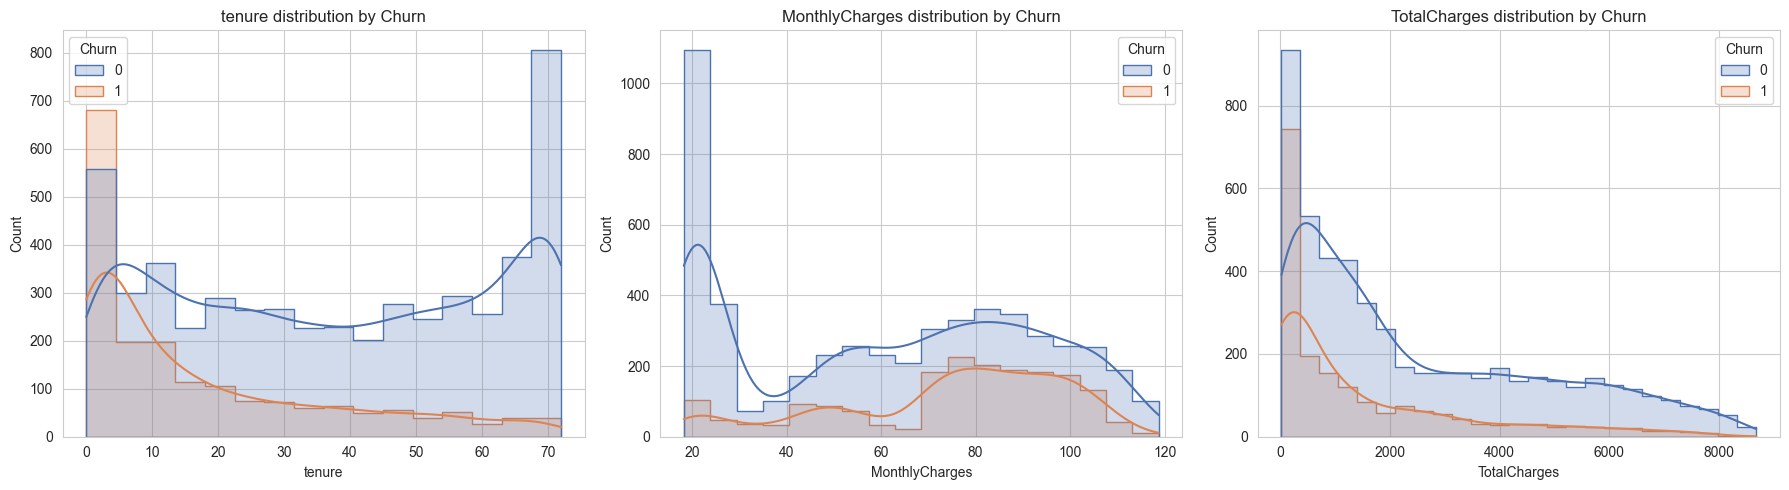

In [11]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax, palette=['#4C72B0', '#DD8452'], element='step')
    ax.set_title(f'{col} distribution by Churn')
plt.tight_layout()
plt.show()

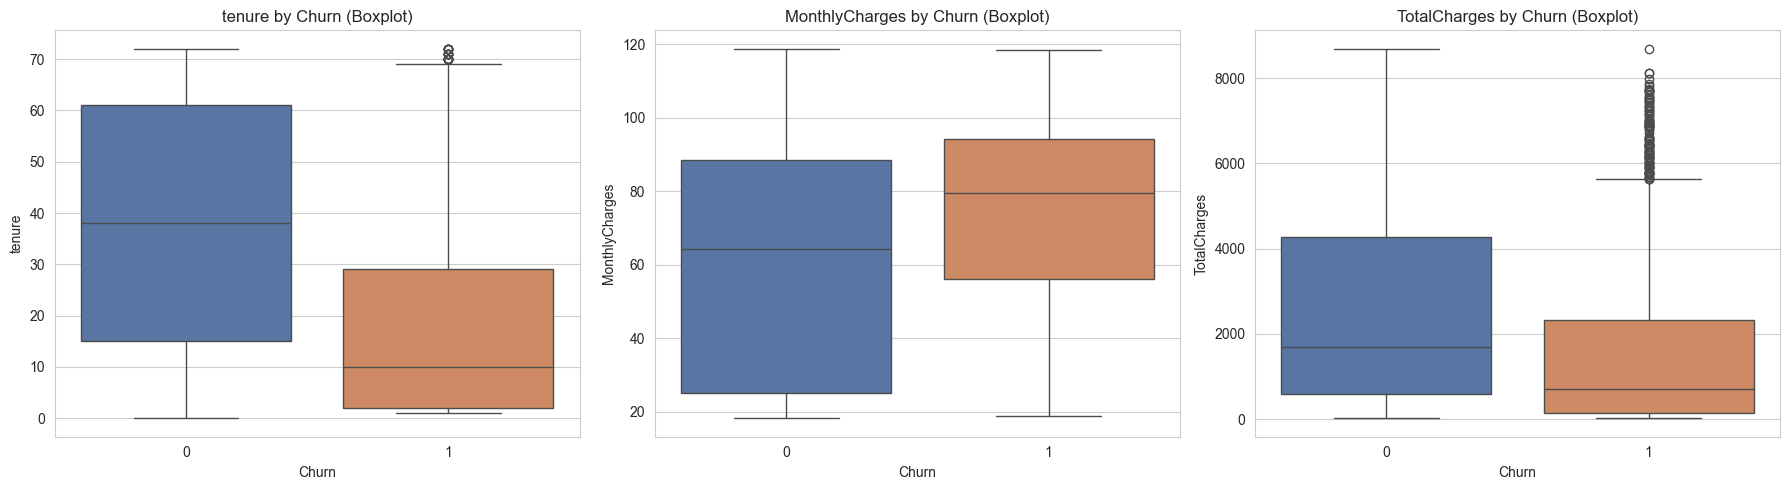

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=ax, palette=['#4C72B0', '#DD8452'])
    ax.set_title(f'{col} by Churn (Boxplot)')
plt.tight_layout()
plt.show()

### 4.4 Correlations among numeric variables

The heatmap summarizes linear correlations for the numeric features and target. It is a directional diagnostic, not a causal finding: low linear correlation does not mean a feature is unimportant to nonlinear models.


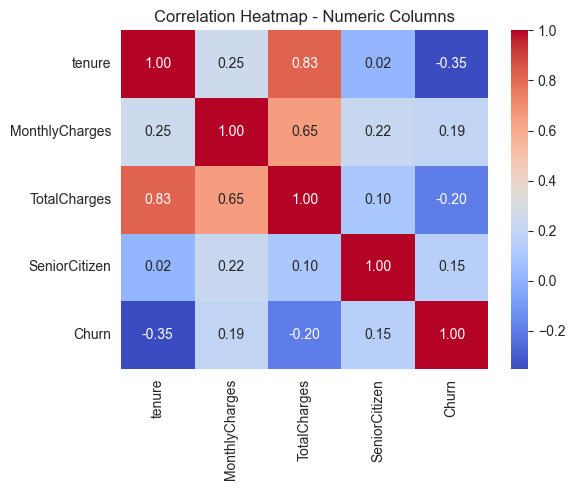

In [13]:
plt.figure(figsize=(6,5))
corr = df[num_cols + ['SeniorCitizen', 'Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numeric Columns')
plt.tight_layout()
plt.show()

### EDA takeaway

The visual analysis is consistent with the final business interpretation: churn is particularly relevant among **month-to-month customers**, customers using **fiber optic service**, those without **technical support or online security**, and customers paying by **electronic check**. **Tenure** also emerges as an important signal—newer customers tend to be more vulnerable to churn.


## 5. Outlier review and capping

Outliers are examined for the three core numerical fields. Rather than deleting customer records, the notebook uses the **IQR rule** to cap values outside the allowed range:

`lower bound = Q1 − 1.5 × IQR`  
`upper bound = Q3 + 1.5 × IQR`

This preserves observations while limiting the influence of extreme values on scale-sensitive models.


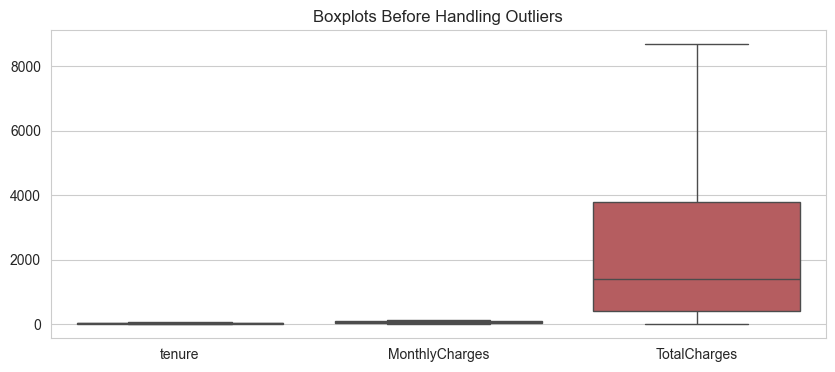

In [14]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df[num_cols], palette=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Boxplots Before Handling Outliers')
plt.show()

In [15]:
def iqr_cap(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((series < lower) | (series > upper)).sum()
    capped = series.clip(lower=lower, upper=upper)
    return capped, n_outliers, lower, upper

for col in ['MonthlyCharges', 'TotalCharges']:
    df[col], n_out, low, up = iqr_cap(df[col])
    print(f"{col}: capped {n_out} outlier(s) (bounds: {low:.1f} - {up:.1f})")

MonthlyCharges: capped 0 outlier(s) (bounds: -46.0 - 171.4)
TotalCharges: capped 0 outlier(s) (bounds: -4674.3 - 8863.2)


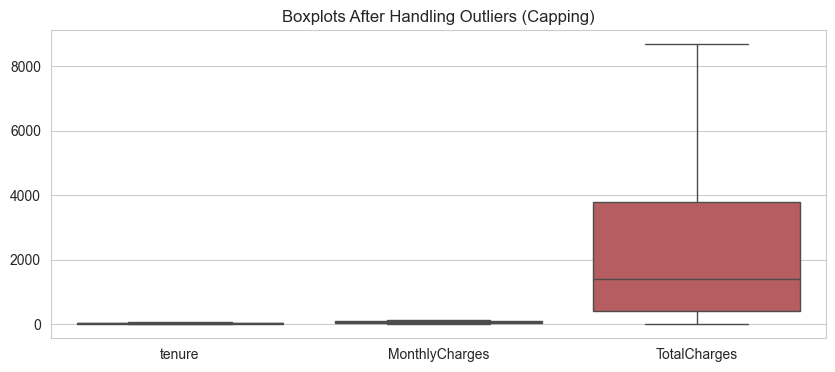

In [16]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df[num_cols], palette=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Boxplots After Handling Outliers (Capping)')
plt.show()

### Why capping instead of deletion?

An extreme charge or tenure can still describe a real customer. Capping retains the customer record and the broader pattern, while making the numeric range more stable for downstream transformations.


## 6. Distribution skewness and log transformation

Skewed numeric distributions can affect models that depend on distance or linear relationships. The notebook measures skewness and applies `log1p` to selected charge variables, which is safe when values can be zero.

The results show the intended effect: the original `TotalCharges` skewness is about **0.964**, while the transformed charge variables have smaller absolute skewness (about **−0.72** to **−0.74**).


In [17]:
print("Skewness before treatment:")
print(df[num_cols].skew())

Skewness before treatment:
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963789
dtype: float64


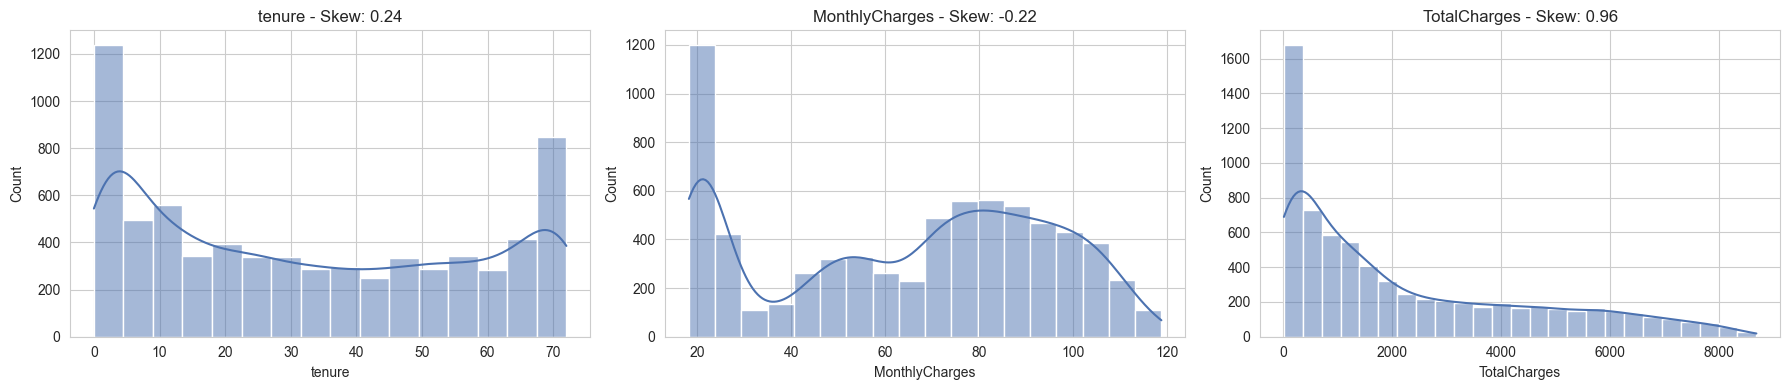

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'{col} - Skew: {df[col].skew():.2f}')
plt.tight_layout()
plt.show()

In [19]:
skewed_cols = ['MonthlyCharges', 'TotalCharges']
for col in skewed_cols:
    df[col + '_log'] = np.log1p(df[col])

print("Skewness after the log transform:")
print(df[[c + '_log' for c in skewed_cols]].skew())

Skewness after the log transform:
MonthlyCharges_log   -0.719017
TotalCharges_log     -0.744502
dtype: float64


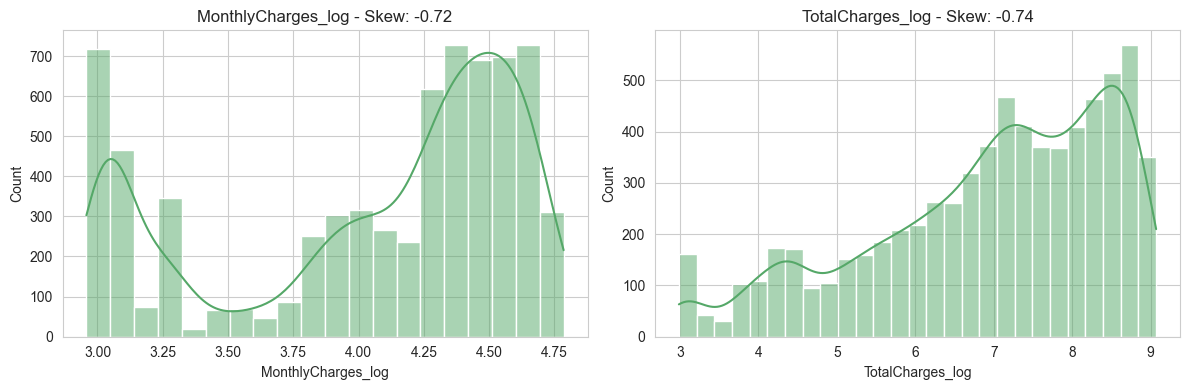

tenure            0.239540
MonthlyCharges   -0.719017
TotalCharges     -0.744502
dtype: float64

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, col in zip(axes, skewed_cols):
    sns.histplot(df[col + '_log'], kde=True, ax=ax, color='#55A868')
    ax.set_title(f'{col}_log - Skew: {df[col+"_log"].skew():.2f}')
plt.tight_layout()
plt.show()

# Replace the original columns with the improved (log) version and drop the originals
# to avoid duplicating the same information
df = df.drop(columns=skewed_cols)
df = df.rename(columns={c + '_log': c for c in skewed_cols})
df[num_cols].skew()

### Transformation hand-off

After the visual check, the transformed charge features replace their previous versions in the working dataset. This keeps the remaining pipeline aligned with the improved distributions while preserving the original analysis in the saved outputs.


## 7. Encode categorical features

Machine-learning estimators require numeric input. The notebook uses an encoding strategy based on the number of unique values:

| Feature type | Encoding | Reason |
|---|---|---|
| Binary categorical fields | Label encoding (0/1) | A compact representation for two categories |
| Multi-category fields | One-hot encoding with `drop_first=True` | Avoids inventing an ordinal order between categories |

The result is a model-ready feature table.


In [21]:
binary_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() == 2]
multi_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() > 2]
print("Binary columns:", binary_cols)
print("Multi-class columns:", multi_cols)

Binary columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [22]:
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
print("Data shape after encoding:", df.shape)
df.head()

Data shape after encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Churn,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,0,3.429137,3.429137,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,0,4.059581,7.544597,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,1,4.004602,4.692723,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,0,3.768153,7.518471,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,1,4.272491,5.028148,...,False,False,False,False,False,False,False,False,True,False


### Encoding result

The prepared dataset has **31 columns** after encoding, including the target. This yields **30 predictive features** before train/test splitting.


## 8. Create training and test sets

The dataset is divided into:

- **80% training data** for preprocessing, cross-validation, tuning, and model fitting
- **20% test data** kept aside for the final unbiased comparison

`stratify=y` preserves the churn proportion in both partitions. The saved split contains **5,634 training rows** and **1,409 test rows**, with a churn rate of about **26.5%** in each.


In [23]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Churn ratio in train:\n", y_train.value_counts(normalize=True))
print("Churn ratio in test:\n", y_test.value_counts(normalize=True))

X_train: (5634, 30) | X_test: (1409, 30)
Churn ratio in train:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn ratio in test:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## 9. Scale numerical features

`StandardScaler` standardizes `tenure`, `MonthlyCharges`, and `TotalCharges` using **training-set statistics only**. This is important because KNN, SVM, and logistic regression are sensitive to feature magnitude.

The descriptive output below confirms that the scaled training variables have a mean near zero and standard deviation near one.


In [24]:
scaler = StandardScaler()
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

X_train_scaled[numeric_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,8.134541e-17,2.585397e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.863556e+00,-2.569155e+00
25%,-9.559779e-01,-7.661207e-01,-6.078228e-01
50%,-1.418632e-01,3.855623e-01,1.872779e-01
75%,9.164859e-01,8.013794e-01,8.410989e-01
max,1.608483e+00,1.274759e+00,1.370397e+00


## 10. Select the most informative features

Feature selection is evaluated from two complementary angles:

1. **ANOVA F-test (`SelectKBest`)** — a univariate statistical association with churn
2. **Random Forest importance** — contribution to impurity reduction in a nonlinear tree ensemble

The next cells compare both rankings and retain the agreed top features for the final model inputs.


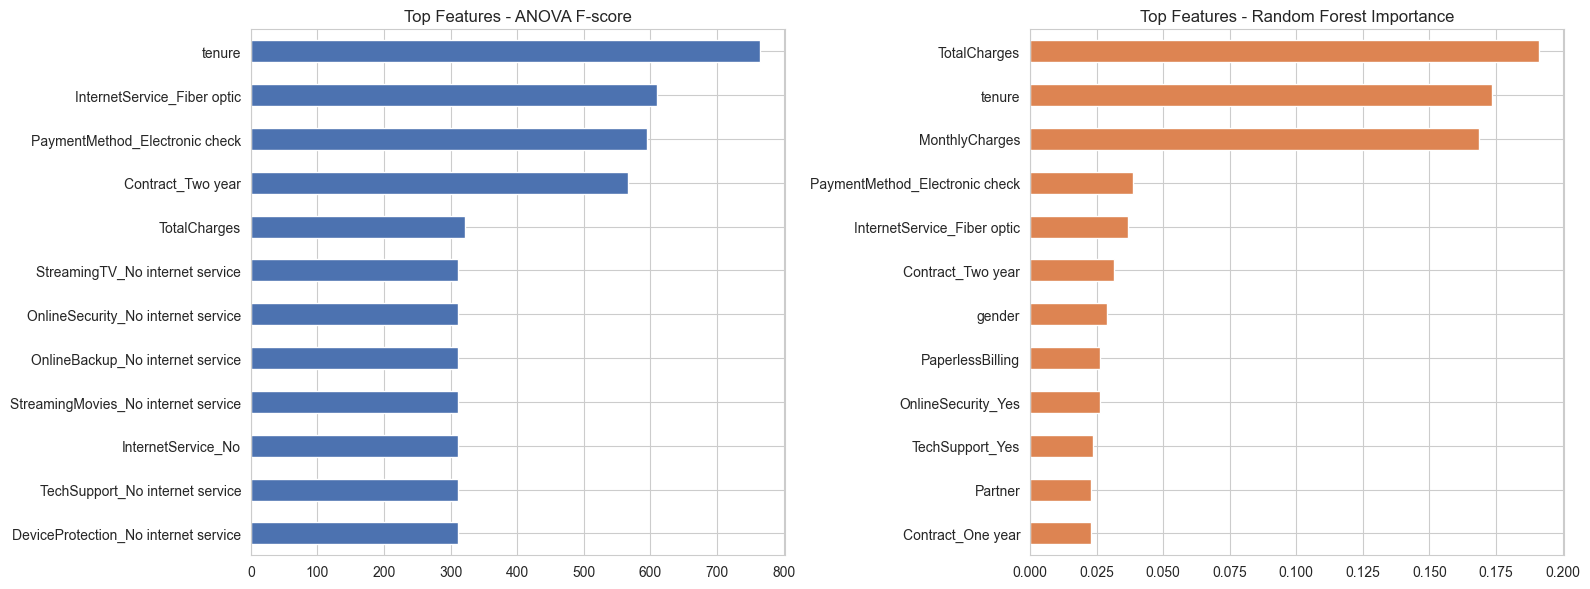


Number of selected features: 19
['Contract_One year', 'Contract_Two year', 'DeviceProtection_No internet service', 'InternetService_Fiber optic', 'InternetService_No', 'MonthlyCharges', 'OnlineBackup_No internet service', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'PaperlessBilling', 'Partner', 'PaymentMethod_Electronic check', 'StreamingMovies_No internet service', 'StreamingTV_No internet service', 'TechSupport_No internet service', 'TechSupport_Yes', 'TotalCharges', 'gender', 'tenure']


In [25]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)
f_scores = pd.Series(selector.scores_, index=X_train_scaled.columns).sort_values(ascending=False)

rf_temp = RandomForestClassifier(n_estimators=200, random_state=42)
rf_temp.fit(X_train_scaled, y_train)
rf_importance = pd.Series(rf_temp.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
f_scores.head(12).sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top Features - ANOVA F-score')
rf_importance.head(12).sort_values().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Top Features - Random Forest Importance')
plt.tight_layout()
plt.show()

top_features = sorted(set(f_scores.head(12).index) | set(rf_importance.head(12).index))
print(f"\nNumber of selected features: {len(top_features)}")
print(top_features)

In [26]:
# Use only the selected features for final training (reduces dimensionality,
# reduces overfitting risk, and speeds up training)
X_train_fs = X_train_scaled[top_features]
X_test_fs = X_test_scaled[top_features]
print(X_train_fs.shape, X_test_fs.shape)

(5634, 19) (1409, 19)


### Feature-selection result

The workflow retains **19 features** for final training. The list includes contract indicators, internet-service variables, monthly and total charges, paperless billing, partnership, electronic-check payment, technical support, gender, and tenure.

This is a dimensionality-reduction step: it focuses the models on the signals supported by the two selection methods while reducing unnecessary complexity.


## 11. Handle class imbalance with SMOTE

Churn is the minority outcome, so a model optimized for raw accuracy could under-detect at-risk customers. The notebook applies **SMOTE** only to the training set, synthesizing new minority-class examples from nearby observations.

| Training class | Before SMOTE | After SMOTE |
|---|---:|---:|
| Stayed (`0`) | 4,139 | 4,139 |
| Churned (`1`) | 1,495 | 4,139 |

The test set is intentionally left unchanged so final evaluation reflects the original customer mix.


In [27]:
print("Churn distribution in train before SMOTE:")
print(y_train.value_counts())

def simple_smote(X, y, minority_label=1, k=5, random_state=42):
    # A simple, transparent from-scratch implementation of SMOTE
    # (used only if the imblearn library isn't available)
    rng = np.random.RandomState(random_state)
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    X_min = X[y == minority_label]
    n_minority = len(X_min)
    n_majority = (y != minority_label).sum()
    n_to_generate = n_majority - n_minority
    if n_to_generate <= 0:
        return X, y

    k_eff = min(k, n_minority - 1) if n_minority > 1 else 1
    nn = NearestNeighbors(n_neighbors=k_eff + 1).fit(X_min)
    neighbors = nn.kneighbors(X_min, return_distance=False)[:, 1:]

    synthetic = np.empty((n_to_generate, X.shape[1]))
    for i in range(n_to_generate):
        idx = rng.randint(0, n_minority)
        nn_idx = neighbors[idx][rng.randint(0, neighbors.shape[1])]
        gap = rng.rand()
        synthetic[i] = X_min[idx] + gap * (X_min[nn_idx] - X_min[idx])

    X_res = np.vstack([X, synthetic])
    y_res = np.concatenate([y, np.full(n_to_generate, minority_label)])
    return X_res, y_res


if IMBLEARN_AVAILABLE:
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_fs, y_train)
else:
    X_bal_arr, y_train_bal = simple_smote(X_train_fs.values, y_train.values, minority_label=1)
    X_train_bal = pd.DataFrame(X_bal_arr, columns=X_train_fs.columns)

print("\nChurn distribution in train after SMOTE:")
print(pd.Series(y_train_bal).value_counts())

Churn distribution in train before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

Churn distribution in train after SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


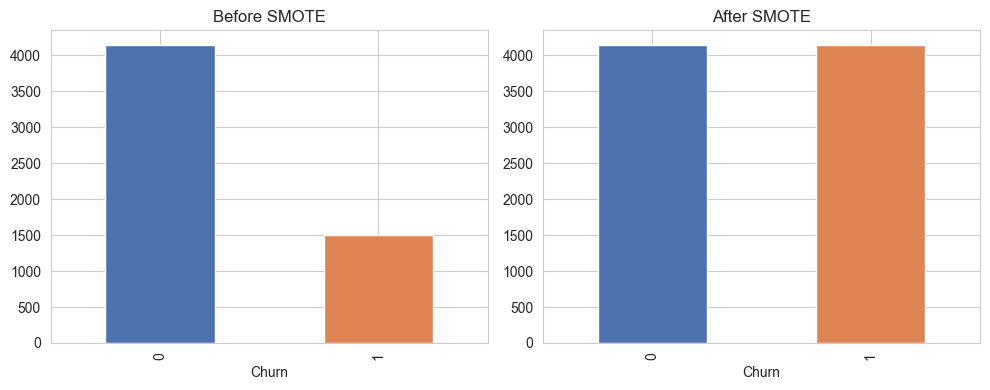

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Before SMOTE')
pd.Series(y_train_bal).value_counts().plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('After SMOTE')
plt.tight_layout()
plt.show()

### Balance check

The side-by-side chart confirms that SMOTE balances the **training** target distribution. This makes the models more attentive to the churn class without contaminating the held-out test set.


## 12. Train and tune candidate models

Six classifiers are trained under one consistent evaluation protocol:

| Step | Design choice |
|---|---|
| Hyperparameter search | `GridSearchCV` |
| Cross-validation | Stratified 5-fold CV |
| Tuning objective | F1-score for the churn class |
| Final validation | Original, untouched test set |

**Why F1-score?** It balances precision (how many predicted churners truly churn) and recall (how many real churners are caught), making it better suited than accuracy for this imbalanced problem.


In [29]:
results = []
fitted_models = {}
roc_data = {}

def run_model(name, base_model, param_grid, cv_folds=5):
    print(f"\n{'='*65}\n🔹 {name}\n{'='*65}")
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    grid = GridSearchCV(base_model, param_grid, scoring='f1', cv=cv, n_jobs=-1)
    grid.fit(X_train_bal, y_train_bal)
    best_model = grid.best_estimator_

    print("Best Hyperparameters:", grid.best_params_)
    print(f"Best CV F1-score: {grid.best_score_:.4f}")

    y_pred = best_model.predict(X_test_fs)
    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_test_fs)[:, 1]
    else:
        y_proba = best_model.decision_function(X_test_fs)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\nTest set  ->  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | "
          f"F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")
    print("\n" + classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    results.append({'Model': name, 'Best Params': str(grid.best_params_), 'Accuracy': acc,
                     'Precision': prec, 'Recall': rec, 'F1-score': f1, 'ROC-AUC': roc_auc})
    fitted_models[name] = best_model
    roc_data[name] = roc_curve(y_test, y_proba)[:2]
    return best_model


🔹 Logistic Regression
Best Hyperparameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-score: 0.7722

Test set  ->  Accuracy: 0.7431 | Precision: 0.5103 | Recall: 0.7968 | F1: 0.6221 | ROC-AUC: 0.8440

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.81      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



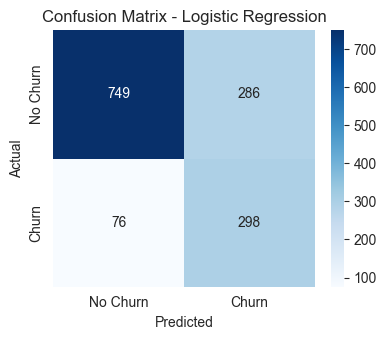

In [30]:
log_reg_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']}
_ = run_model('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42), log_reg_grid)


🔹 KNN
Best Hyperparameters: {'n_neighbors': 15, 'weights': 'distance'}
Best CV F1-score: 0.8265

Test set  ->  Accuracy: 0.7360 | Precision: 0.5018 | Recall: 0.7380 | F1: 0.5974 | ROC-AUC: 0.7986

              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.80      1035
       Churn       0.50      0.74      0.60       374

    accuracy                           0.74      1409
   macro avg       0.69      0.74      0.70      1409
weighted avg       0.78      0.74      0.75      1409



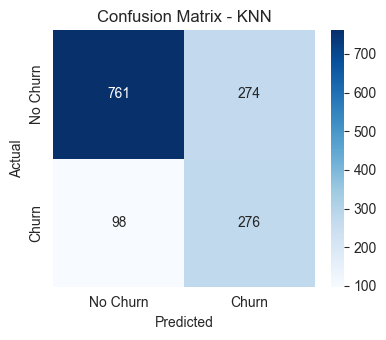

In [31]:
knn_grid = {'n_neighbors': [5, 9, 15, 21], 'weights': ['uniform', 'distance']}
_ = run_model('KNN', KNeighborsClassifier(), knn_grid)


🔹 SVM
Best Hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-score: 0.7934

Test set  ->  Accuracy: 0.7431 | Precision: 0.5105 | Recall: 0.7807 | F1: 0.6173 | ROC-AUC: 0.8059

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



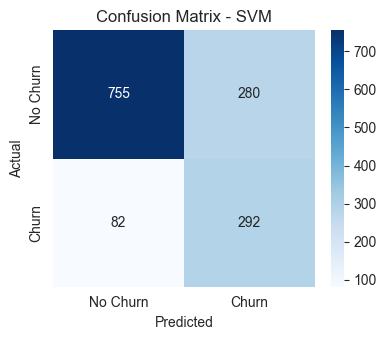

In [32]:
svm_grid = {'C': [1, 10], 'kernel': ['rbf'], 'gamma': ['scale']}
_ = run_model('SVM', SVC(probability=True, random_state=42), svm_grid)


🔹 Decision Tree
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Best CV F1-score: 0.7807

Test set  ->  Accuracy: 0.7197 | Precision: 0.4819 | Recall: 0.7460 | F1: 0.5855 | ROC-AUC: 0.7788

              precision    recall  f1-score   support

    No Churn       0.89      0.71      0.79      1035
       Churn       0.48      0.75      0.59       374

    accuracy                           0.72      1409
   macro avg       0.68      0.73      0.69      1409
weighted avg       0.78      0.72      0.73      1409



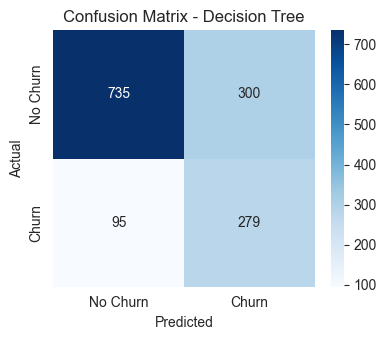

In [33]:
dt_grid = {'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 10], 'criterion': ['gini', 'entropy']}
_ = run_model('Decision Tree', DecisionTreeClassifier(random_state=42), dt_grid)


🔹 Random Forest
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-score: 0.8333

Test set  ->  Accuracy: 0.7622 | Precision: 0.5444 | Recall: 0.6390 | F1: 0.5879 | ROC-AUC: 0.8056

              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.83      1035
       Churn       0.54      0.64      0.59       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.76      0.77      1409



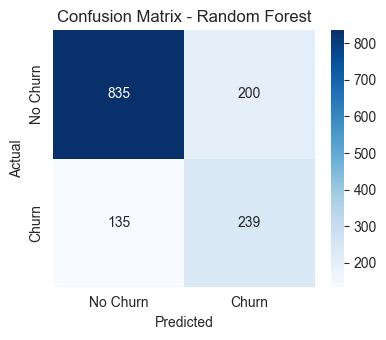

In [34]:
rf_grid = {'n_estimators': [100, 200], 'max_depth': [10, None], 'min_samples_split': [2, 5]}
_ = run_model('Random Forest', RandomForestClassifier(random_state=42), rf_grid)


🔹 XGBoost
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV F1-score: 0.8035

Test set  ->  Accuracy: 0.7630 | Precision: 0.5383 | Recall: 0.7513 | F1: 0.6272 | ROC-AUC: 0.8324

              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.54      0.75      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



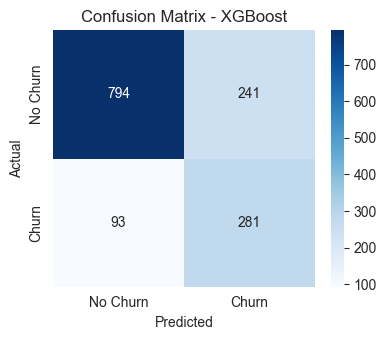

In [35]:
if XGB_AVAILABLE:
    xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)
else:
    xgb_base = XGBClassifier(random_state=42)   # GradientBoostingClassifier fallback

xgb_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
_ = run_model('XGBoost' if XGB_AVAILABLE else 'XGBoost (fallback: GradientBoosting)', xgb_base, xgb_grid)

## 13. Compare model performance

All models are ranked by **test-set F1-score**, the primary selection metric. The following table is a concise record of the saved run.

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| XGBoost | 0.763 | 0.538 | 0.751 | **0.627** | 0.832 |
| Logistic Regression | 0.743 | 0.510 | **0.797** | 0.622 | **0.844** |
| SVM | 0.743 | 0.510 | 0.781 | 0.617 | 0.806 |
| KNN | 0.736 | 0.502 | 0.738 | 0.597 | 0.799 |
| Random Forest | 0.762 | **0.544** | 0.639 | 0.588 | 0.806 |
| Decision Tree | 0.720 | 0.482 | 0.746 | 0.586 | 0.779 |

**Interpretation:** XGBoost has the best F1-score, while Logistic Regression has the strongest recall and ROC-AUC. The preferred model therefore depends on whether the business prioritizes the balance of precision/recall (XGBoost) or catching the maximum possible number of churners (Logistic Regression).


In [36]:
results_df = pd.DataFrame(results).sort_values('F1-score', ascending=False).reset_index(drop=True)
results_df

,Model,Best Params,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.762952,0.538314,0.751337,0.627232,0.832379
1,Logistic Regression,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.743080,0.510274,0.796791,0.622129,0.843967
2,SVM,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.743080,0.510490,0.780749,0.617336,0.805916
3,KNN,"{'n_neighbors': 15, 'weights': 'distance'}",0.735983,0.501818,0.737968,0.597403,0.798610
4,Random Forest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.762243,0.544419,0.639037,0.587946,0.805640
5,Decision Tree,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.719659,0.481865,0.745989,0.585519,0.778784


### Metric comparison chart

The bar chart below makes the trade-offs visible across all five metrics. In a retention program, consider the operational cost of contacting non-churners alongside the cost of missing genuine churners.


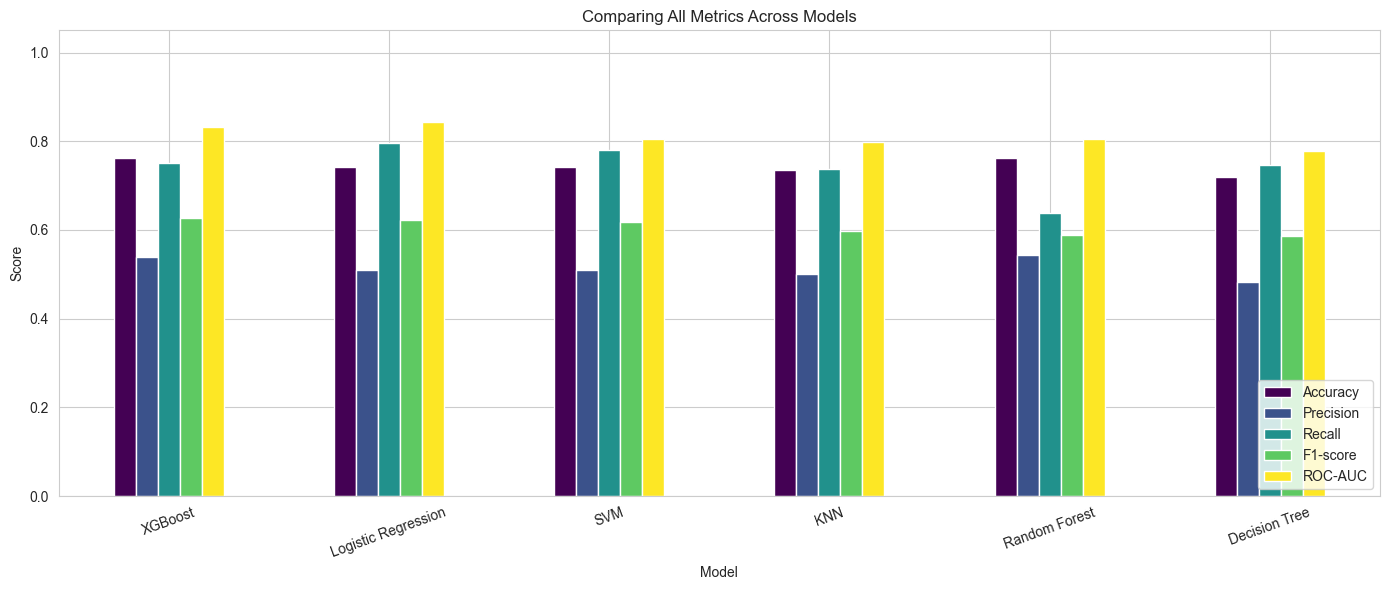

In [37]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
plot_df = results_df.set_index('Model')[metrics_to_plot]

plot_df.plot(kind='bar', figsize=(14, 6), colormap='viridis')
plt.title('Comparing All Metrics Across Models')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### ROC curves

ROC curves compare the true-positive rate against the false-positive rate across possible decision thresholds. A larger area under the curve (ROC-AUC) means stronger ability to separate churners from non-churners overall.


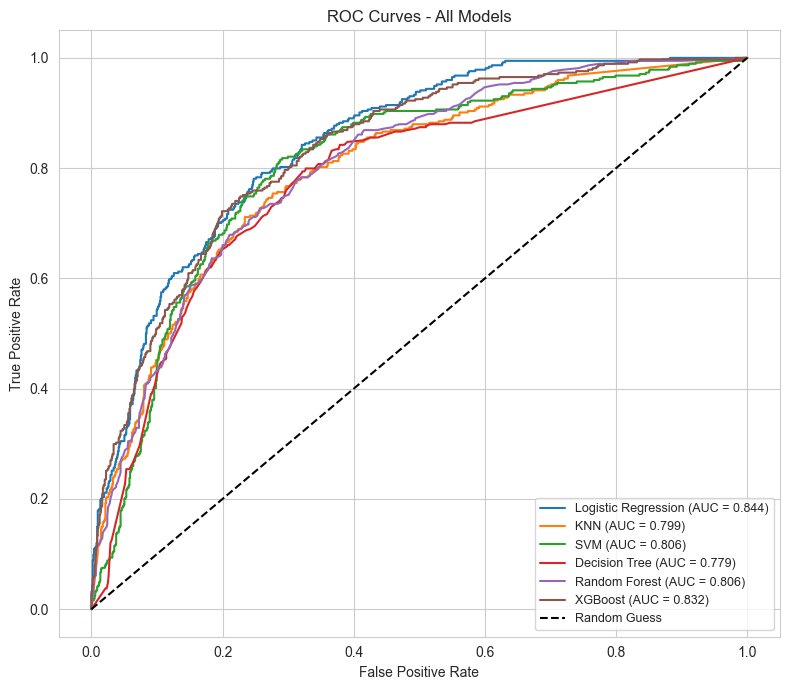

In [38]:
plt.figure(figsize=(8, 7))
for name, (fpr, tpr) in roc_data.items():
    auc_val = results_df.loc[results_df['Model'] == name, 'ROC-AUC'].values[0]
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 14. Best-model review

Using test-set **F1-score** as the selection rule, the notebook selects **XGBoost**.

### Saved best-model result

| Metric | Value |
|---|---:|
| Accuracy | 0.763 |
| Precision | 0.538 |
| Recall | 0.751 |
| F1-score | **0.627** |
| ROC-AUC | 0.832 |

The next cells identify the selected model programmatically and show feature importance when the estimator exposes it.


In [39]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
print(f"🏆 Best model based on F1-score: {best_model_name}")
results_df.iloc[0]

🏆 Best model based on F1-score: XGBoost


Model                                                    XGBoost
Best Params    {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...
Accuracy                                                0.762952
Precision                                               0.538314
Recall                                                  0.751337
F1-score                                                0.627232
ROC-AUC                                                 0.832379
Name: 0, dtype: object

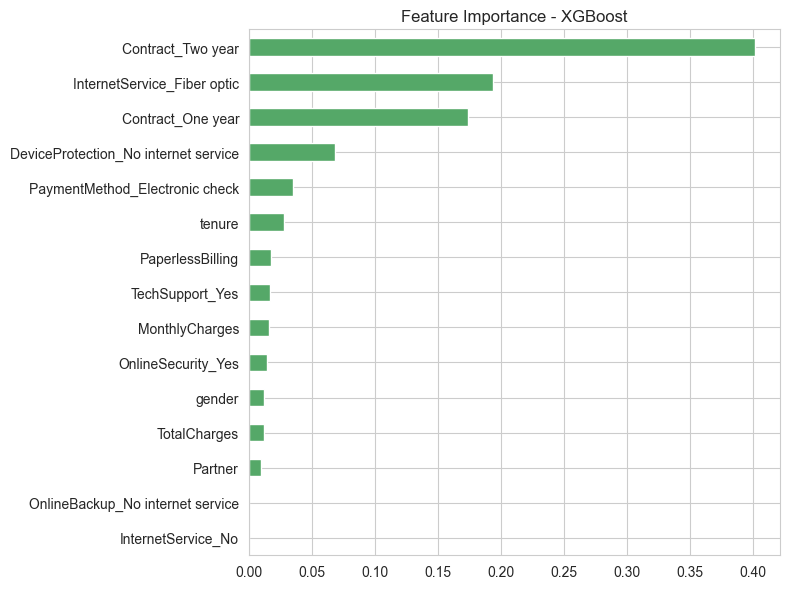

In [40]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train_fs.columns).sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    importances.head(15).sort_values().plot(kind='barh', color='#55A868')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(best_model.coef_[0], index=X_train_fs.columns).sort_values()
    plt.figure(figsize=(8, 6))
    coefs.plot(kind='barh', color='#4C72B0')
    plt.title(f'Feature Coefficients - {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print("This model doesn't expose feature_importances_ or coef_ directly (e.g. KNN/SVM).")

## 15. Persist modeling artifacts

The final code cell saves the trained XGBoost model, the fitted scaler, and the selected-feature list. Keeping these artifacts together is necessary to apply the model consistently to future customer records.

> When deploying, use the same column order, transformations, and decision threshold that were validated here.


In [41]:

import joblib

# Save XGBoost model
xgb_model = fitted_models["XGBoost"]

# Save model
joblib.dump(xgb_model, "model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save selected features
joblib.dump(top_features, "features.pkl")

print("All files saved successfully!")


All files saved successfully!


## 16. Conclusions and retention recommendations

### What the analysis says

The saved run demonstrates that customer churn can be predicted with useful discrimination. **XGBoost** provides the best balance between precision and recall according to F1-score, detecting roughly **75%** of actual churners in the held-out test set.

### Practical signals to prioritize

| Signal | Suggested action |
|---|---|
| Month-to-month contract | Offer a carefully targeted upgrade path to longer-term plans |
| Low tenure | Trigger early-life onboarding and retention journeys |
| No technical support / online security | Bundle or promote support and protection services |
| Fiber optic service | Investigate price, experience, and service-quality friction |
| Electronic-check payment | Encourage lower-friction automatic payment methods |

### Recommended next steps

1. Score active customers on a regular schedule and route high-risk customers to a retention workflow.
2. Set a decision threshold based on the cost of an offer versus the value of preventing a churn.
3. Test retention interventions with controlled experiments rather than assuming correlation is causation.
4. Refit and monitor the model as customer behavior, prices, and offers change.

### Limitations

- The dataset is synthetic; validate the findings against real operational data before making business decisions.
- Results come from one held-out test split; nested cross-validation would provide a more robust estimate.
- The preprocessing approach is educational; production should place imputation, transformation, and feature selection inside a fitted pipeline to prevent leakage.
- Additional feature engineering—such as number of subscribed add-ons or spend relative to customer segment—may improve performance.

---

**Bottom line:** Use the model as a prioritization tool, not an automatic decision-maker. It can focus retention resources on customers most likely to benefit from timely outreach.
